In [1]:
print('hello world')

hello world


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [5]:
!pip install matplotlib seaborn scikit-learn pandas


  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seabo

In [ ]:
df = pd.read_csv("student_data.csv")
print(df.head(5))

print("Rows and Columns:", df.shape)


   Student_ID         Name   Age  Gender        Department      Grade  \
0        1362  Student_362  23.0  Female              Arts  Excellent   
1        1074   Student_74  18.0  Female  Computer Science  Excellent   
2        1375  Student_375  28.0    Male  Computer Science  Excellent   
3        1156  Student_156  23.0    Male       Engineering  Excellent   
4        1105  Student_105  29.0     NaN       Mathematics       Good   

   Attendance  Marks      City  Study_Hours  
0        96.0   42.0    Boston          4.5  
1        67.0   75.0  New York          5.6  
2        89.0   57.0   Seattle          6.0  
3        71.0   76.0    Dallas          3.5  
4        89.0   69.0    Boston          3.7  
Rows and Columns: (500, 10)


In [10]:
print("\n========== Missing Values ==========")
print(df.isnull().sum())


print("\n========== Percentage of Missing Values ==========")

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)


print("\n========== Descriptive Statistics ==========")
print(df.describe())


print("\n========== Dataset Information ==========")
print(df.info())


========== Missing Values ==========
Student_ID      0
Name            0
Age            20
Gender         20
Department     20
Grade          20
Attendance     20
Marks          20
City           20
Study_Hours    20
dtype: int64

========== Percentage of Missing Values ==========
Student_ID     0.0
Name           0.0
Age            4.0
Gender         4.0
Department     4.0
Grade          4.0
Attendance     4.0
Marks          4.0
City           4.0
Study_Hours    4.0
dtype: float64

========== Descriptive Statistics ==========
        Student_ID         Age  Attendance       Marks  Study_Hours
count   500.000000  480.000000  480.000000  480.000000   480.000000
mean   1250.500000   22.900000   74.927083   66.687500     4.234583
std     144.481833    3.799022   14.870383   21.340814     1.923748
min    1001.000000   17.000000   50.000000   35.000000     0.200000
25%    1125.750000   20.000000   62.000000   50.000000     3.100000
50%    1250.500000   23.000000   74.000000   65.000000    

In [31]:
dataset = pd.read_csv("student_data.csv")
dataset.head(3)

,Student_ID,Name,Age,Gender,Department,Grade,Attendance,Marks,City,Study_Hours
0,1362,Student_362,23.0,Female,Arts,Excellent,96.0,42.0,Boston,4.5
1,1074,Student_74,18.0,Female,Computer Science,Excellent,67.0,75.0,New York,5.6
2,1375,Student_375,28.0,Male,Computer Science,Excellent,89.0,57.0,Seattle,6.0


In [21]:
dataset.isnull().sum()


Student_ID      0
Name            0
Age             0
Gender         20
Department     20
Grade          20
Attendance      0
Marks           0
City           20
Study_Hours     0
dtype: int64

In [41]:
# dataset["Attendance"].fillna(dataset["Attendance"].mean(), inplace=True)
imputer = SimpleImputer(strategy="mean")

dataset[["Attendance"]] = imputer.fit_transform(dataset[["Attendance"]])
dataset[["Marks"]] = imputer.fit_transform(dataset[["Marks"]])
dataset[["Study_Hours"]] = imputer.fit_transform(dataset[["Study_Hours"]])
dataset[["Age"]] = imputer.fit_transform(dataset[["Age"]])

print(dataset.head(4))

   Student_ID         Name   Age  Gender        Department      Grade  \
0        1362  Student_362  23.0  Female              Arts  Excellent   
1        1074   Student_74  18.0  Female  Computer Science  Excellent   
2        1375  Student_375  28.0    Male  Computer Science  Excellent   
3        1156  Student_156  23.0    Male       Engineering  Excellent   

   Attendance  Marks      City  Study_Hours  
0        96.0   42.0    Boston          4.5  
1        67.0   75.0  New York          5.6  
2        89.0   57.0   Seattle          6.0  
3        71.0   76.0    Dallas          3.5  


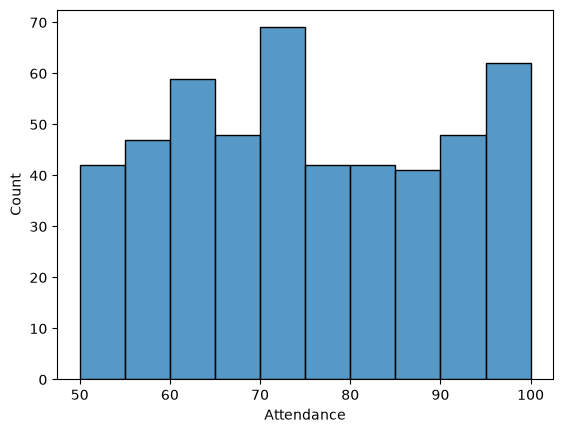

In [42]:
sns.histplot(data=dataset, x="Attendance")
plt.show()

In [43]:
dataset.describe()

,Student_ID,Age,Attendance,Marks,Study_Hours
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,22.900000,74.927083,66.687500,4.234583
std,144.481833,3.722111,14.569332,20.908769,1.884802
min,1001.000000,17.000000,50.000000,35.000000,0.200000
25%,1125.750000,20.000000,63.000000,50.750000,3.200000
50%,1250.500000,23.000000,74.927083,66.000000,4.234583
75%,1375.250000,26.000000,87.000000,81.250000,5.100000
max,1500.000000,29.000000,100.000000,200.000000,20.000000


In [44]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(dataset[["Attendance"]])

dataset["Attendance_ss"] = ss.transform(dataset[["Attendance"]])

dataset.head(3)

,Student_ID,Name,Age,Gender,Department,Grade,Attendance,Marks,City,Study_Hours,Attendance_ss
0,1362,Student_362,23.0,Female,Arts,Excellent,96.0,42.0,Boston,4.5,1.447837
1,1074,Student_74,18.0,Female,Computer Science,Excellent,67.0,75.0,New York,5.6,-0.544639
2,1375,Student_375,28.0,Male,Computer Science,Excellent,89.0,57.0,Seattle,6.0,0.966895


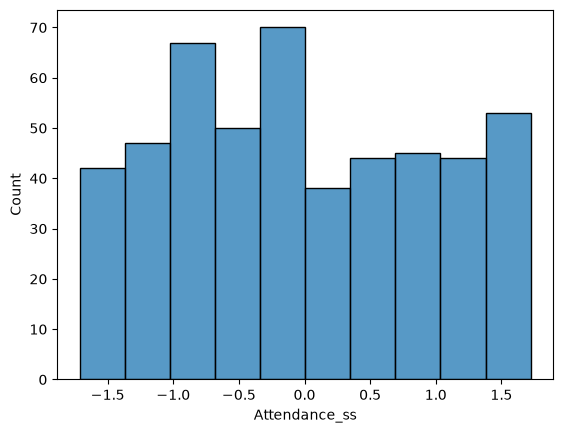

In [45]:
sns.histplot(data=dataset, x="Attendance_ss")
plt.show()

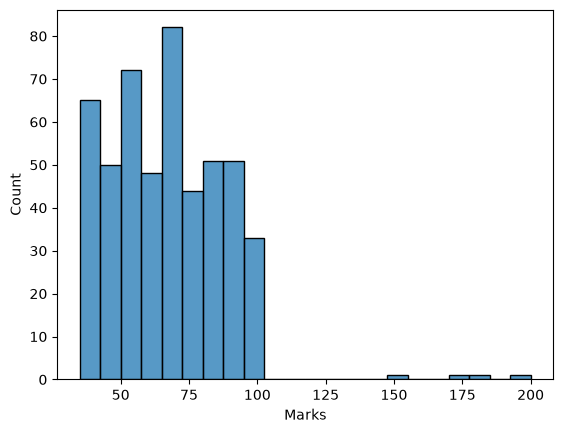

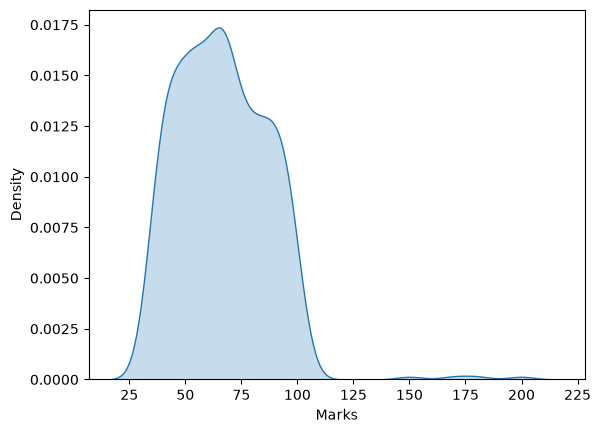

In [46]:
sns.histplot(data=dataset, x="Marks")
plt.show()

sns.kdeplot(data=dataset, x="Marks", fill=True)
plt.show()

In [47]:

from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

# Normalization
dataset["Marks_MM"] = mm.fit_transform(dataset[["Marks"]])

dataset.head(3)

,Student_ID,Name,Age,Gender,Department,Grade,Attendance,Marks,City,Study_Hours,Attendance_ss,Marks_MM
0,1362,Student_362,23.0,Female,Arts,Excellent,96.0,42.0,Boston,4.5,1.447837,0.042424
1,1074,Student_74,18.0,Female,Computer Science,Excellent,67.0,75.0,New York,5.6,-0.544639,0.242424
2,1375,Student_375,28.0,Male,Computer Science,Excellent,89.0,57.0,Seattle,6.0,0.966895,0.133333


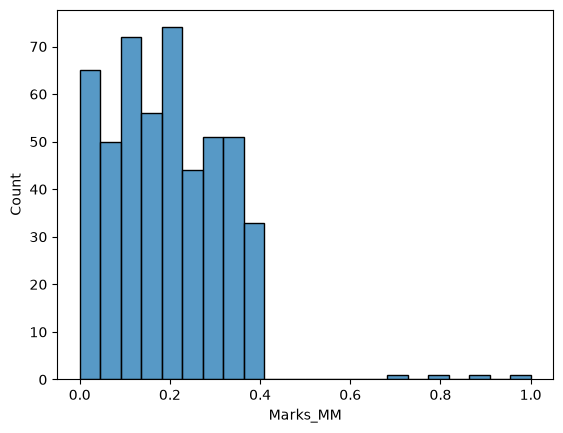

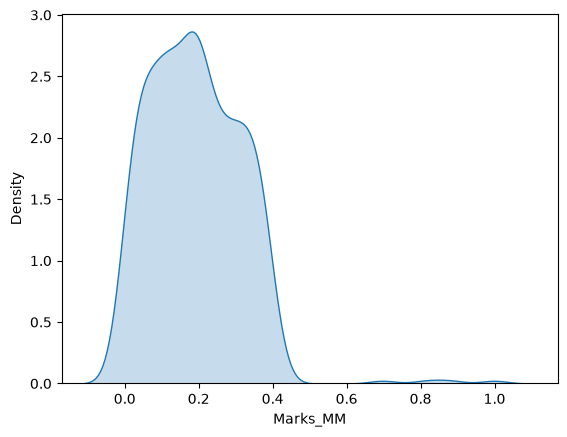

In [48]:
sns.histplot(data=dataset, x="Marks_MM")
plt.show()

sns.kdeplot(data=dataset, x="Marks_MM", fill=True)
plt.show()

In [49]:
dataset.shape
dataset.drop_duplicates(inplace=True)
dataset.shape

(500, 12)

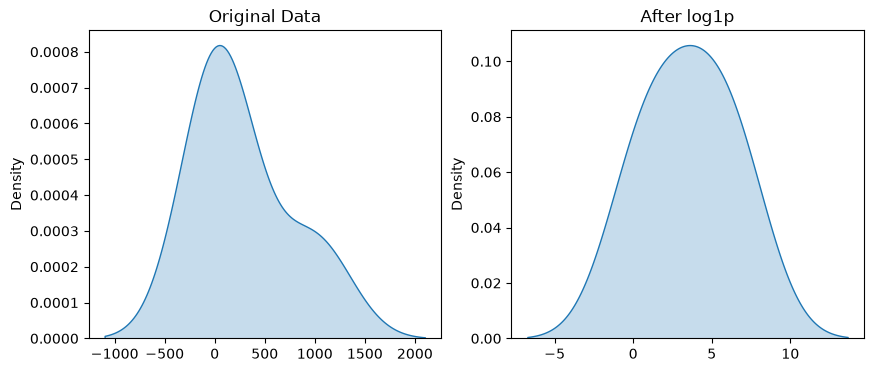

In [37]:
# //conert the non normal distribution data to normal distribution of data
import numpy as np

x = [0, 10, 100, 1000]

fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.kdeplot(x=x, fill=True, ax=ax[0])
ax[0].set_title("Original Data")

sns.kdeplot(x=np.log1p(x), fill=True, ax=ax[1])
ax[1].set_title("After log1p")

plt.show()

In [51]:
dataset["Gender"] = dataset["Gender"].fillna(dataset["Gender"].mode()[0])
dataset["Department"] = dataset["Department"].fillna(dataset["Department"].mode()[0])
dataset["Grade"] = dataset["Grade"].fillna(dataset["Grade"].mode()[0])
dataset["City"] = dataset["City"].fillna(dataset["City"].mode()[0])
print(dataset.isnull().sum())

Student_ID       0
Name             0
Age              0
Gender           0
Department       0
Grade            0
Attendance       0
Marks            0
City             0
Study_Hours      0
Attendance_ss    0
Marks_MM         0
dtype: int64


In [55]:
dataset.corr(numeric_only=True)["Marks"].sort_values()

Age             -0.071313
Attendance_ss   -0.058061
Attendance      -0.058061
Study_Hours      0.008307
Student_ID       0.039606
Marks            1.000000
Marks_MM         1.000000
Name: Marks, dtype: float64

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score



X = dataset.drop(columns=["Marks","Marks_MM","Attendance", "Student_ID", "Name"])
y = dataset["Marks"]

# ==========================
# Encoding categorical data
# ==========================

X = pd.get_dummies(X, drop_first=True)

print("Shape :", X.shape)
print("\nColumns:")
print(X.columns)


# Model

lr = LinearRegression()

best_score = -999
best_features = None

print("\n" + "="*60)
print("Sequential Feature Selection Results")
print("="*60)

for k in range(1, len(X.columns)):

    sfs = SequentialFeatureSelector(
        estimator=lr,
        n_features_to_select=k,
        direction="forward",
        scoring="r2",
        cv=5
    )

    sfs.fit(X, y)

    selected_features = X.columns[sfs.get_support()]

    score = cross_val_score(
        lr,
        X[selected_features],
        y,
        cv=5,
        scoring="r2"
    ).mean()

    print(f"\n{k} Features Selected")
    print("Features :", list(selected_features))
    print("Score    :", round(score, 4))

    if score > best_score:
        best_score = score
        best_features = selected_features



print("\n" + "="*60)
print("BEST COMBINATION")
print("="*60)

print("Best Features:")
print(list(best_features))

print("\nBest Score:")
print(round(best_score, 4))

Shape : (500, 16)

Columns:
Index(['Age', 'Study_Hours', 'Attendance_ss', 'Gender_Male',
       'Department_Business', 'Department_Computer Science',
       'Department_Engineering', 'Department_Mathematics', 'Grade_Excellent',
       'Grade_Good', 'Grade_Poor', 'City_Chicago', 'City_Dallas',
       'City_Houston', 'City_New York', 'City_Seattle'],
      dtype='str')

Sequential Feature Selection Results

1 Features Selected
Features : ['Grade_Excellent']
Score    : -0.0211

2 Features Selected
Features : ['Age', 'Grade_Excellent']
Score    : -0.0183

3 Features Selected
Features : ['Age', 'Grade_Excellent', 'City_Chicago']
Score    : -0.0181

4 Features Selected
Features : ['Age', 'Department_Mathematics', 'Grade_Excellent', 'City_Chicago']
Score    : -0.0194

5 Features Selected
Features : ['Age', 'Department_Computer Science', 'Department_Mathematics', 'Grade_Excellent', 'City_Chicago']
Score    : -0.0206

6 Features Selected
Features : ['Age', 'Department_Computer Science', 'Depart